# Hierarchical Clustering - UPGMA

---
## Learning Objectives

1. Implement a distance-based phylogeny neighbor joining algorithm
1. Understanding of hierarchical clustering
1. Manipulation of arrays and lists in Python


---
## Imports
You will need to install a two new packages to properly render your phylogenetic trees. Using your preferred package manager, install both [`biopython`](https://biopython.org/) and `matplotlib` into your virtual environments.

For example:
```bash
$ micromamba create -n module06 -c bioconda -c conda-forge python numpy matplotlib biopython
```

In [26]:
from typing import List, Tuple, Dict
from io import StringIO

import matplotlib.pyplot as plt
from Bio import Phylo
import numpy as np
import textdistance


---
## Background

Today we will implement a distance-based phylogenetic tree construction method using the Neighbor-Joining (NJ) algorithm and Smith-Waterman local alignment scores. Unlike UPGMA (Unweighted Pair Group Method using Arithmetic averages), NJ produces unrooted trees and does not assume a constant evolutionary rate across lineages, making it more biologically realistic for analyzing sequence relationships.

We will use HIV-1 reverse transcriptase sequences to construct our phylogenetic tree. The Smith-Waterman algorithm will be used to generate pairwise local alignment scores, which will then be converted into distances for tree construction. This approach is particularly suitable for HIV sequence analysis as it:
1. Handles sequence variations effectively through local alignment
2. Accounts for potential rate heterogeneity across different viral strains
3. Does not assume a molecular clock

The ultimate output will be an unrooted phylogenetic tree representing the evolutionary relationships between the HIV-1 sequences, visualized using the ete3 library. This method provides insights into viral diversity and evolutionary patterns while avoiding the assumptions of simpler hierarchical clustering approaches.

The key innovations of this implementation are:
- Use of Smith-Waterman for sensitive local alignment scoring
- Implementation of Neighbor-Joining for unrooted tree construction
- More biologically realistic evolutionary model

## Neighbor-Joining Algorithm

**Input**: Distance matrix $D$ for $n$ sequences

**Initialization**:
- Let $n$ be the number of sequences
- Assign each sequence $i$ to its own leaf node
- Initialize tree $T$ with leaf nodes

**Iteration**:
While $n > 2$:
1. Calculate Q-matrix where:
   $Q(i,j) = (n-2)d(i,j) - \sum_{k=1}^n d(i,k) - \sum_{k=1}^n d(j,k)$

2. Find pair $(i,j)$ with minimum $Q(i,j)$

3. Calculate branch lengths:
   $d_i = \frac{d(i,j) + (r_i - r_j)/(n-2)}{2}$
   $d_j = d(i,j) - d_i$
   where $r_i = \sum_{k=1}^n d(i,k)$

4. Create new node $k$
   - Add branches from $k$ to $i$ and $j$ with lengths $d_i$ and $d_j$

5. Update distances to remaining nodes $x$:
   $d(k,x) = \frac{d(i,x) + d(j,x) - d(i,j)}{2}$

6. Remove nodes $i$ and $j$
7. Add node $k$ to active nodes
8. $n = n - 1$

**Termination**:
When $n = 2$ with remaining nodes $i$ and $j$:
- Add final branch between $i$ and $j$ with length $d(i,j)$
- Return unrooted tree $T$

---
## Distance metrics for comparing sequences

### Smith-Waterman
This was previously implemented. Feel free to import if you know how...or Copy & Paste.



In [27]:
def read_fasta(filepath: str) -> dict[str, str]:
    """Reads sequences from FASTA file.

    Args:
        filename (str): Path to FASTA file containing HIV RT sequences

    Returns:
        Dict[str, str]: Dictionary mapping sequence IDs to sequences

    Examples:
        >>> seqs = read_fasta("lafayette_SARS_RT.fasta")
        >>> len(seqs) > 0
        True
    """

     #initialize storage
    sequences = {}
    current_id = None
    current_seq = []

    #open the fasta file
    with open(filepath,'r', encoding='utf-8') as fasta_file:
        for line in fasta_file:
            #remove whitespace/newline from the line
            line = line.strip()
            #if the line starts with '>'
            if line.startswith(">"):
                #save previous sequence before starting the new one
                if current_id is not None:
                    sequences[current_id] = "".join(current_seq)

                #extract sequence ID by removing ">"
                current_id = line[1:].split()[0]
                current_seq = []
            else:
                current_seq.append(line)
    #save the last sequence
    if current_id is not None:
        sequences[current_id] = "".join(current_seq)
    return sequences

In [28]:
filepath = "data/lafayette_SARS_RT.fasta"
sequences = read_fasta(filepath)


In [29]:
def smith_waterman(
    sequence1: str,
    sequence2: str,
    match_score: float = 2.0,
    mismatch_penalty: float = -1.0,
    gap_penalty: float = -1.0
) -> float:
    """Implements Smith-Waterman local alignment algorithm.

    Args:
        sequence1 (str): First HIV RT sequence
        sequence2 (str): Second HIV RT sequence
        match_score (float): Score for matching characters
        mismatch_penalty (float): Penalty for mismatched characters
        gap_penalty (float): Penalty for gaps

    Returns:
        float: Normalized similarity score between sequences

    Examples:
        >>> seq1 = "ACGT"
        >>> seq2 = "ACGT"
        >>> smith_waterman(seq1, seq2)
        1.0
    """
    #sequence lengths for sequences being aligned
    num_rows = len(sequence1) + 1
    num_cols = len(sequence2) + 1

    #initialize scoring matrix with zeroes
    score_matrix = np.zeros((num_rows, num_cols), dtype = float)

    #Track max score in matrix
    max_score = 0.0

    #Fill scoring matrix
    for row_ind in range(1, num_rows):
        for col_ind in range(1, num_cols):
            #start by determining match/mismatch score
            if sequence1[row_ind - 1] == sequence2[col_ind - 1]:
                diag_score = float(score_matrix[row_ind -1][col_ind -1] + match_score)
            else: 
                diag_score = float(score_matrix[row_ind -1][col_ind -1] + mismatch_penalty)

            #gap scores and ensure value is a float
            up_score = float(score_matrix[row_ind - 1, col_ind] + gap_penalty)
            left_score = float(score_matrix[row_ind - 1, col_ind] + gap_penalty)

            #if all scores are <0, select 0
            current_score = max(0.0, diag_score, left_score, up_score)

            #store score
            score_matrix[row_ind, col_ind] = current_score
            #update max score
            if current_score > max_score:
                max_score = current_score
    return max_score


In [30]:
def build_distance_matrix(sequences: Dict[str, str]) -> Tuple[np.ndarray, List[str]]:
    """Builds DISTANCE (not similiarity) matrix using Smith-Waterman scores.

    Args:
        sequences (Dict[str, str]): Dictionary of HIV RT sequences

    Returns:
        Tuple[np.ndarray, List[str]]: Distance matrix and list of sequence IDs

    Examples:
        >>> seqs = read_fasta("lafayette_SARS_RT.fasta")
        >>> mat, ids = build_distance_matrix(seqs)
        >>> mat[0:3, 0:3]  # Show 3x3 slice of distance matrix
        array([[0.000, 0.004, 0.012],
              [0.004, 0.000, 0.012],
              [0.012, 0.012, 0.000]])
        >>> len(ids)  # Number of sequences
        19
    """

    # Get sequence IDs in a list to preserve order
    sequence_ids = list(sequences.keys())

    # Total number of sequences
    num_sequences = len(sequence_ids)

    # Similarity matrix
    similarity_matrix = np.zeros((num_sequences, num_sequences), dtype=float)

    # Compute pairwise Smith–Waterman scores
    for row_index in range(num_sequences):
        for col_index in range(row_index + 1, num_sequences):
            seq_id_row = sequence_ids[row_index]
            seq_id_col = sequence_ids[col_index]

            # Compute local alignment score between two sequences
            similarity_score = smith_waterman(
                sequences[seq_id_row],
                sequences[seq_id_col]
            )

            # Fill symmetric similarity matrix
            similarity_matrix[row_index, col_index] = float(similarity_score)
            similarity_matrix[col_index, row_index] = float(similarity_score)

    # Maximum similarity score across all pairs (converts to distances)
    max_similarity = float(np.max(similarity_matrix))

    # Distance matrix: distance(i,j) = max_similarity - similarity(i,j)
    distance_matrix = np.zeros((num_sequences, num_sequences), dtype=float)
    for row_index in range(num_sequences):
        for col_index in range(num_sequences):
            if row_index == col_index:
                # Distance from sequence to itself is zero
                distance_matrix[row_index, col_index] = 0.0
            else:
                distance_matrix[row_index, col_index] = max_similarity - similarity_matrix[row_index, col_index]

    return distance_matrix, sequence_ids




In [31]:
def to_newick(tree_dict, current_node_label):
    """
    Recursively convert tree dictionary into Newick format starting from current_node_label.
    Parameters:
        tree_dict (dict): tree structure {parent: [(child, length), ...]}
        current_node_label (str): node to convert
    Returns:
        str: Newick representation of subtree
    """
    # Leaf is node with no children
    if current_node_label not in tree_dict:
        return current_node_label

    # Otherwise, recursively convert each child
    newick_parts = []
    for child_label, branch_length in tree_dict[current_node_label]:
        child_newick = to_newick(tree_dict, child_label)
        newick_parts.append(f"{child_newick}:{branch_length:.5f}")

    # Join children with commas and wrap in parentheses
    newick_convert = "(" + ",".join(newick_parts) + ")"
    return newick_convert


In [32]:
def add_edge(tree_dict, parent_label, child_label, branch_length):
    """
    Add edge (parent -> child) with given branch length to tree dictionary.
    Parameters:
        tree_dict (dict): tree structure {parent: [(child, length), ...]}
        parent_label (str): label of parent node
        child_label (str): label of child node
        branch_length (float): branch length from parent to child
    """
    # If new species add to dictionary
    if parent_label not in tree_dict:
        tree_dict[parent_label] = []
    tree_dict[parent_label].append((child_label, float(branch_length)))

In [33]:
def neighbor_joining(
    distance_matrix: np.ndarray,
    labels: List[str]
) -> str:
    """Implements Neighbor-Joining algorithm for phylogenetic tree construction.

    Args:
        distance_matrix (np.ndarray): Distance matrix from Smith-Waterman scores
        labels (List[str]): Sequence identifiers

    Returns:
        str: Newick format tree string

    Examples:
        >>> seqs = read_fasta("lafayette_SARS_RT.fasta")
        >>> mat, ids = build_distance_matrix(seqs)
        >>> tree = neighbor_joining(mat, ids)
        >>> tree.startswith("((DM1:0.002,DM2:0.002)")  # Start of Newick string
        True
        >>> tree.count(",")  # Number of separators in tree
        18
    """
       # Work on copies so original inputs are not modified
    current_distance_matrix = distance_matrix.astype(float)
    current_labels = labels.copy()

    # Initialize dictionary for tree
    tree_dict = {}

    # Track last internal node created
    last_internal_node = None

    # Main Neighbor-Joining loop: continue until only two nodes remain
    while len(current_labels) > 2:
        # Find number of current taxa
        num_taxa = len(current_labels)

        # Sum of distances from taxon i to all others (ri)
        row_sums = np.sum(a=current_distance_matrix, axis=1).astype(np.float64)

        # Q-matrix: used by Neighbor-Joining to choose next pair to join
        # Formula: Q(i,j) = (n - 2)*d(i,j) - ri - rj
        # The pair with the smallest Q(i,j) is joined next.
        q_matrix = np.zeros((num_taxa, num_taxa), dtype=float)

        # Compute Q(i,j) = (n-2)*d(i,j) - ri - rj for all i != j
        for row_index in range(num_taxa):
            for col_index in range(num_taxa):
                if row_index != col_index:
                    q_matrix[row_index, col_index] = (
                        (num_taxa - 2) * current_distance_matrix[row_index, col_index]
                        - row_sums[row_index]
                        - row_sums[col_index]
                    )

        # Find pair (i,j) with minimum Q value
        min_index_flat = np.argmin(q_matrix)
        index_i, index_j = np.unravel_index(min_index_flat, q_matrix.shape)

        # Ensure consistent ordering (i < j) for removal
        if index_j < index_i:
            index_i, index_j = index_j, index_i

        # Compute branch lengths from new internal node to i & j
        delta_value = (row_sums[index_i] - row_sums[index_j]) / (num_taxa - 2)
        limb_length_i = (current_distance_matrix[index_i, index_j] + delta_value) / 2.0
        limb_length_j = current_distance_matrix[index_i, index_j] - limb_length_i

        # Create new internal node label
        new_internal_label = f"U{len(tree_dict) + 1}"
        # Track last internal node
        last_internal_node = new_internal_label

        # Record edges from new internal node to two joined taxa
        add_edge(tree_dict, new_internal_label, current_labels[index_i], limb_length_i)
        add_edge(tree_dict, new_internal_label, current_labels[index_j], limb_length_j)

        # Compute distances from new internal node to all remaining taxa k
        new_distances = []
        for other_index in range(num_taxa):
            if other_index not in (index_i, index_j):
                distance_ik = current_distance_matrix[index_i, other_index]
                distance_jk = current_distance_matrix[index_j, other_index]
                distance_ij = current_distance_matrix[index_i, index_j]
                distance_uk = (distance_ik + distance_jk - distance_ij) / 2.0
                new_distances.append(distance_uk)

        # Build revised (n-1) x (n-1) distance matrix
        new_num_taxa = num_taxa - 1
        new_distance_matrix = np.zeros((new_num_taxa, new_num_taxa), dtype=float)
        new_label_list = []

        # Fill revised matrix without i & j
        new_row_index = 0
        for old_row_index in range(num_taxa):
            if old_row_index in (index_i, index_j):
                continue
            new_col_index = 0
            for old_col_index in range(num_taxa):
                if old_col_index in (index_i, index_j):
                    continue
                new_distance_matrix[new_row_index, new_col_index] = current_distance_matrix[old_row_index, old_col_index]
                new_col_index += 1
            new_label_list.append(current_labels[old_row_index])
            new_row_index += 1

        # Append new internal node distances as last row/column
        new_distance_matrix[-1, :-1] = new_distances
        new_distance_matrix[:-1, -1] = new_distances
        new_label_list.append(new_internal_label)

        # Update current matrix, labels for next iteration
        current_distance_matrix = new_distance_matrix
        current_labels = new_label_list

    # At end, two labels remain, connect directly
    final_label_a = current_labels[0]
    final_label_b = current_labels[1]
    final_distance = float(current_distance_matrix[0, 1])

    # Record final edge
    add_edge(tree_dict, final_label_a, final_label_b, float(final_distance))

    # Convert full unrooted tree to Newick with last internal node
    newick_string = to_newick(tree_dict, last_internal_node) + ";"

    return newick_string

In [34]:
def plot_tree(newick_tree: str) -> None:
    """Plots a phylogenetic tree from a Newick string using Biopython and Matplotlib.

    The tree is rendered in a rectangular layout with smaller leaf labels and
    added margins to reduce overlap between labels and branches.

    Args:
        newick_tree (str): Tree in Newick format

    Returns:
        None: Displays the plotted tree
    """
    handle = StringIO(newick_tree)
    tree = Phylo.read(handle, "newick")

    fig, ax = plt.subplots(figsize=(8, 10))

    Phylo.draw(
        tree,
        axes=ax,
        do_show=False,
        label_func=lambda clade: clade.name if clade.is_terminal() else None,
    )
    for text in ax.texts:
        text.set_fontsize(6)              # shrink labels
    ax.margins(x=0.1, y=0.05)             # extra padding around tree

    plt.tight_layout()
    plt.show()


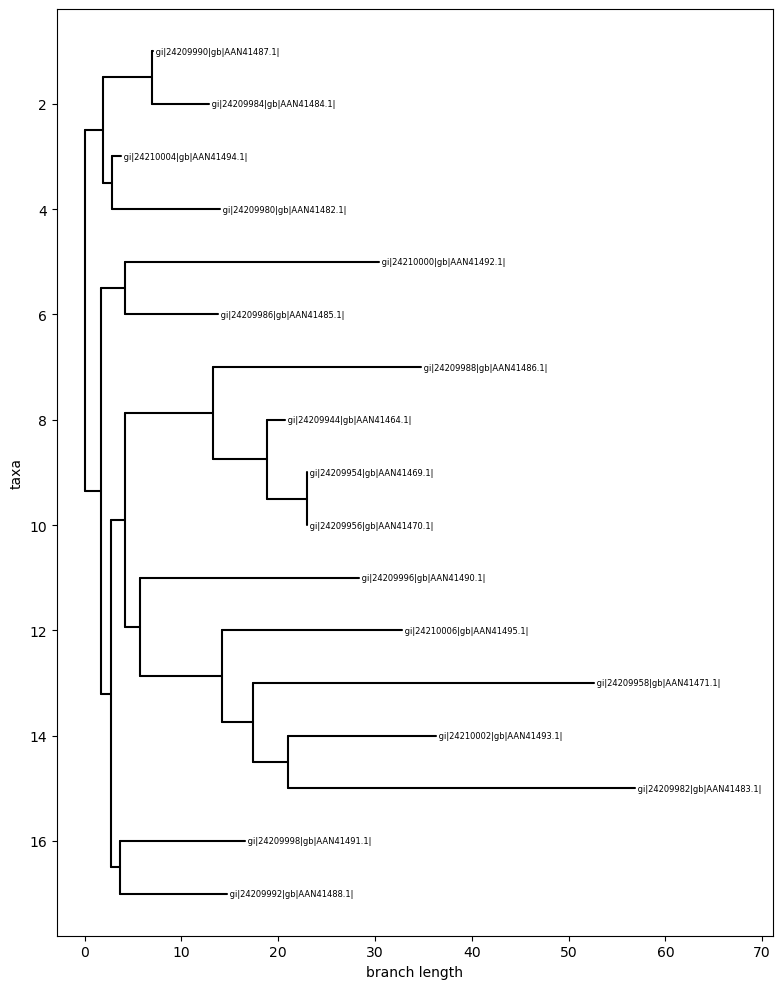

In [36]:
if __name__ == "__main__":
    # Read HIV RT sequences
    sequences = read_fasta("data/lafayette_SARS_RT.fasta")
    
    # Build distance matrix using Smith-Waterman
    dist_matrix, seq_ids = build_distance_matrix(sequences)
    
    # Generate unrooted tree using Neighbor-Joining
    tree = neighbor_joining(dist_matrix, seq_ids)
    
    # Plot tree
    plot_tree(tree)